# Handling Missing Data in Pandas

Data in tutorials usually arrives clean. Real-world data rarely does. Most interesting datasets have missing values, and different sources mark them in different ways.

In this section, we will:
- Explain how Pandas represents missing data.
- Demonstrate built-in Pandas tools for handling missing data.

## What is Missing Data?

Missing data comes from data entry errors, collection problems, or merging datasets that cover different time frames. Pandas represents it in three ways:
- `None`: A Python object, used for missing values in object columns such as strings.
- `NaN`: A special floating-point value, "Not a Number", used for missing numbers.
- `NA`: A sentinel value introduced in Pandas 1.0 that works across all data types, including the ones where `NaN` does not fit.

## Missing Data Conventions

There are two general strategies for marking missing values in a table:
1. **Masking**: Keep a separate Boolean array that says which cells are missing. This costs extra storage.
2. **Sentinel value**: Reserve a special value to mean "missing", such as -9999 for integers or `NaN` for floats. This removes one value from the valid range.

Pandas uses both.



## Handling Missing Data in Pandas

Pandas offers several functions to detect, handle, and visualize missing data. Below are some key functions and techniques:

### 1. Detecting Missing Data

Pandas provides functions to identify missing data:


In [1]:
import pandas as pd
import numpy as np

# Example DataFrame with missing values
data = {
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': ['a', 'b', None, 'd']
}

df = pd.DataFrame(data)
df

,A,B,C
0,1.0,5.0,a
1,2.0,NaN,b
2,NaN,NaN,None
3,4.0,8.0,d


Detect missing values:

In [2]:
df.isnull()

,A,B,C
0,False,False,False
1,False,True,False
2,True,True,True
3,False,False,False


Count missing values in each column:

In [3]:
df.isnull().sum()

,0
A,1
B,2
C,1



### 2. Dropping Missing Data

Sometimes, it may be appropriate to drop rows or columns containing missing values:


In [4]:
# Drop rows with any missing values
df.dropna()

,A,B,C
0,1.0,5.0,a
3,4.0,8.0,d


In [5]:
# Drop columns with any missing values
df.dropna(axis='columns')

""
0
1
2
3


In [6]:
# Drop rows where all elements are missing
df.dropna(how='all')

,A,B,C
0,1.0,5.0,a
1,2.0,NaN,b
3,4.0,8.0,d


In [7]:
# Keep rows with at least n non-missing values
df.dropna(thresh=2)  # Require that many non-NA values. Cannot be combined with how.

,A,B,C
0,1.0,5.0,a
1,2.0,NaN,b
3,4.0,8.0,d



### 3. Filling Missing Data

In other cases, it might be more useful to fill missing values with specific values or computed statistics:


In [8]:
# Fill missing values with a specific value
df.fillna(0)

,A,B,C
0,1.0,5.0,a
1,2.0,0.0,b
2,0.0,0.0,0
3,4.0,8.0,d


In [9]:
# Fill missing values with the mean of the column
df.fillna(df.mean(numeric_only=True))

,A,B,C
0,1.000000,5.0,a
1,2.000000,6.5,b
2,2.333333,6.5,None
3,4.000000,8.0,d


In [10]:
# Forward fill (propagate the last valid observation forward)
df.ffill()

,A,B,C
0,1.0,5.0,a
1,2.0,5.0,b
2,2.0,5.0,b
3,4.0,8.0,d


In [11]:
# Backward fill (propagate the next valid observation backward)
df.bfill()

,A,B,C
0,1.0,5.0,a
1,2.0,8.0,b
2,4.0,8.0,d
3,4.0,8.0,d



### 4. Interpolating Missing Data

For some datasets, interpolating missing values can be more appropriate. Pandas provides an `interpolate` method to perform linear or other types of interpolation:


In [12]:
# Linear interpolation
df[['A', 'B']].interpolate()

,A,B
0,1.0,5.0
1,2.0,6.0
2,3.0,7.0
3,4.0,8.0


### 5. Advanced Missing Data Handling with `pd.NA`

Pandas 1.0 (January 2020) introduced the `pd.NA` scalar. Unlike `NaN`, which is a float, `pd.NA` works in any column type.

#### Key Differences Between `pd.NA` and `NaN`:

- **Works across data types**: `pd.NA` can sit in integer, float, string and boolean columns. `NaN` only fits in float columns.
- **Nullable data types**: `pd.NA` comes with nullable dtypes (`Int64`, `boolean`, `string`) that keep their type when a value is missing. With `NaN`, an integer column with one missing value gets upcast to `float`.
- **Three-valued logic**: Comparisons with `pd.NA` return `NA` rather than `False`, so a missing value does not silently pass or fail a filter.

Below are examples of `pd.NA` in a DataFrame.


In [13]:
# Using pd.NA for missing values
df['D'] = pd.Series([1, pd.NA, 3, pd.NA], dtype='Int64')
df.info()  # Output: Int64 (Nullable Integer Type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       3 non-null      float64
 1   B       2 non-null      float64
 2   C       3 non-null      object 
 3   D       2 non-null      Int64  
dtypes: Int64(1), float64(2), object(1)
memory usage: 264.0+ bytes


In [14]:
# Operations with pd.NA
df['D'] = df['D'].fillna(0)  # Example of filling with 0
df['D']

,D
0,1
1,0
2,3
3,0


### 6. The Contagious Nature of Missing Data

In data analytics, missing data can propagate through calculations, affecting the results. This phenomenon is often referred to as the "contagious" nature of missing data. Understanding how missing values influence computations is crucial for accurate data analysis.

#### Stand-alone Examples

When performing arithmetic operations with missing values (`np.nan`), the result is typically also missing.

In [15]:
# Addition
result = 1 + np.nan
print("1 + np.nan =", result)

# Multiplication
result = 5 * np.nan
print("5 * np.nan =", result)

# Comparison
print("np.nan == np.nan:", np.nan == np.nan)

1 + np.nan = nan
5 * np.nan = nan
np.nan == np.nan: False


These examples demonstrate that any operation involving a missing value results in a missing or undefined outcome.

#### Example in a DataFrame

Missing data can contaminate entire computations within a DataFrame.

In [16]:
# Create a simple DataFrame with missing values
df = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, 7, 8]
})

print("Original DataFrame:")
print(df)

Original DataFrame:
     A    B
0  1.0  5.0
1  2.0  NaN
2  NaN  7.0
3  4.0  8.0


Compute a new column `C` as the sum of columns `A` and `B`:

In [17]:
df['C'] = df['A'] + df['B']
print("\nDataFrame after adding column C (A + B):")
df


DataFrame after adding column C (A + B):


,A,B,C
0,1.0,5.0,6.0
1,2.0,NaN,NaN
2,NaN,7.0,NaN
3,4.0,8.0,12.0


In rows where either `A` or `B` is missing, the result in `C` is also missing. The missing values have "contaminated" the computation.


### 7. Visualizing Missing Data with `missingno`

The `missingno` package plots where the missing values are. Seeing the pattern helps you decide how to handle them.

#### Installing `missingno`

```bash
pip install missingno
```

#### Visualizing Missing Data

It has four main plots:

1. **Bar Plot**: Count of non-missing values per column.
2. **Matrix Plot**: The data as a grid, with missing cells blanked out.
3. **Heatmap**: How strongly the missingness of one column correlates with another.
4. **Dendrogram**: Groups columns whose values tend to be missing together.

Below are examples of each:


In [18]:
# Sample dataset
df_grocery = pd.DataFrame({
    'CustomerID': [f'CUST_{str(i).zfill(3)}' for i in range(1, 21)],
    'PurchaseDate': np.random.choice(pd.to_datetime(['2024-09-17', '2024-09-18', '2024-09-19']), 20),
    'Product': ['Milk', 'Bread', pd.NA, 'Cheese', 'Butter', 'Milk', 'Bananas', 'Tomatoes',
                'Beef', 'Rice', 'Pasta', 'Tomatoes', 'Onions', 'Potatoes', 'Carrots',
                'Lettuce', 'Cereal', 'Juice', 'Yogurt', 'Milk'],
    'Quantity': np.random.choice([1, 2, 3, np.nan], 20),
    'UnitPrice': [3.5, 2.0, 0.2, 5.0, 4.0, 3.5, 0.3, 0.8, 8.0, 1.0,
                  1.5, 0.8, 0.6, 0.4, 0.3, 1.2, 3.0, 2.5, 0.9, 3.5]
})

df_grocery['TotalAmount'] = df_grocery['Quantity'] * df_grocery['UnitPrice']

df_grocery.head(2)

,CustomerID,PurchaseDate,Product,Quantity,UnitPrice,TotalAmount
0,CUST_001,2024-09-19,Milk,2.0,3.5,7.0
1,CUST_002,2024-09-17,Bread,2.0,2.0,4.0


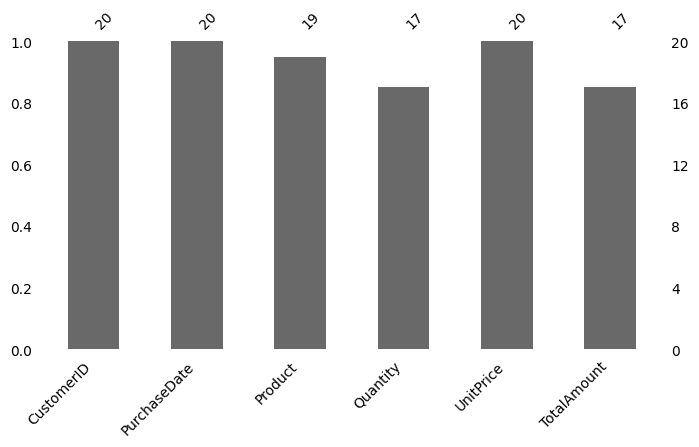

In [20]:
import missingno as msno

# Visualize missing data with a bar plot
msno.bar(df_grocery, figsize=(8, 4), fontsize=10);

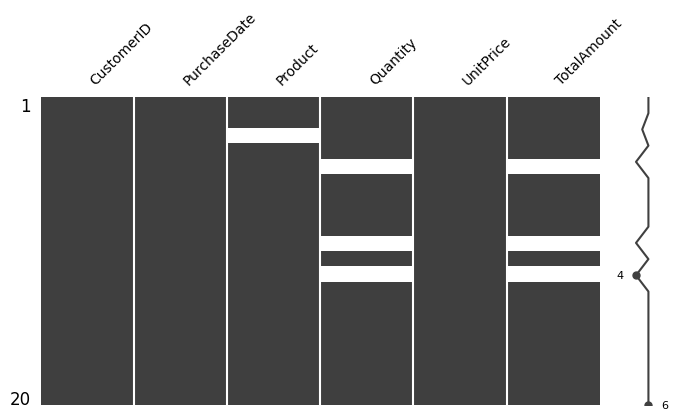

In [21]:
# Visualize missing data with a matrix plot
msno.matrix(df_grocery, figsize=(8, 4), fontsize=10);

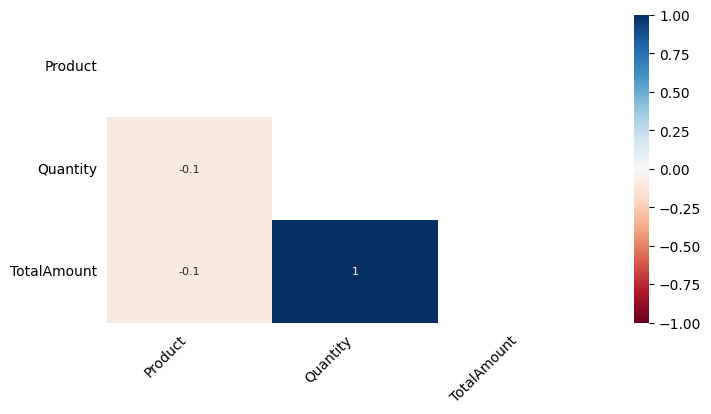

In [22]:
# Visualize missing data with a heatmap to see correlations of missing values
msno.heatmap(df_grocery, figsize=(8, 4), fontsize=10);

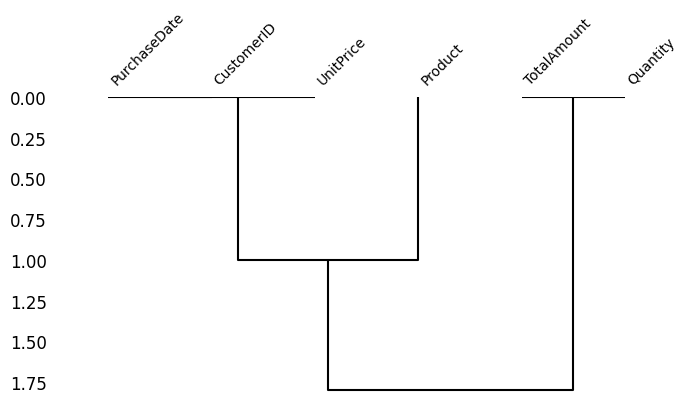

In [23]:
# Visualize missing data with a dendrogram
msno.dendrogram(df_grocery, figsize=(8, 4), fontsize=10);


### Summary

Every real dataset has gaps. Pandas gives you tools to find them (`isnull`), remove them (`dropna`), fill them (`fillna`, `ffill`, `bfill`, `interpolate`) and see them (`missingno`). Which one you pick depends on the data and on what the analysis can tolerate.


### Exercise: handle missing values
Fill in the TODOs in the next cell:
- Show missing counts per column
- Impute numeric columns with the median
- Impute categorical columns with the mode
- Print the imputed DataFrame

In [ ]:
# Tiny demo DataFrame with missing values
df = pd.DataFrame({
    "age": [25, 32, pd.NA, 28, pd.NA],
    "income": [50000, pd.NA, 42000, pd.NA, 61000],
    "city": ["NY", "SF", pd.NA, "LA", "NY"]
})

df

In [ ]:
# TODO: Show missing values per column
# print(...)

# TODO: Impute numeric columns with the median
# numeric_cols = ...
# for col in numeric_cols:
#     df[col] = ...

# TODO: Impute categorical columns with the mode
# categorical_cols = ...
# for col in categorical_cols:
#     mode_value = ...
#     if not mode_value.empty:
#         df[col] = ...

# TODO: Print the imputed DataFrame
# print(...)